In [2]:
from pathlib import Path
import xml.etree.ElementTree as ET

import cv2
import matplotlib.pyplot as plt

# notebook lives in: project/notebooks/
PROJECT_ROOT = Path("..").resolve()
IMAGES_DIR = PROJECT_ROOT / "data" / "raw" 
ANN_DIR = PROJECT_ROOT / "data" / "annotations"

IMAGES_DIR, ANN_DIR

(PosixPath('/home/wiebe/Desktop/Robotic/AE4317/testing_nn/data/raw'),
 PosixPath('/home/wiebe/Desktop/Robotic/AE4317/testing_nn/data/annotations'))

In [4]:
IMAGE_NAME = "test.jpg"  # <- change this
img_path = IMAGES_DIR / IMAGE_NAME
xml_path = ANN_DIR / (Path(IMAGE_NAME).stem + ".xml")

print("Image:", img_path)
print("XML:", xml_path)
print("Image exists:", img_path.exists())
print("XML exists:", xml_path.exists())

Image: /home/wiebe/Desktop/Robotic/AE4317/testing_nn/data/raw/test.jpg
XML: /home/wiebe/Desktop/Robotic/AE4317/testing_nn/data/annotations/test.xml
Image exists: True
XML exists: True


In [5]:
def read_voc(xml_file: Path):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    objs = []
    for obj in root.findall("object"):
        label = obj.findtext("name")
        bnd = obj.find("bndbox")
        xmin = int(float(bnd.findtext("xmin")))
        ymin = int(float(bnd.findtext("ymin")))
        xmax = int(float(bnd.findtext("xmax")))
        ymax = int(float(bnd.findtext("ymax")))
        objs.append((label, xmin, ymin, xmax, ymax))

    return objs

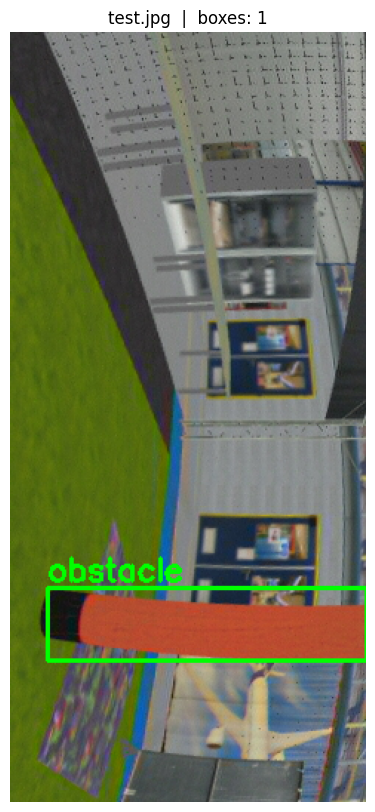

In [6]:
assert img_path.exists(), f"Image not found: {img_path}"

img_bgr = cv2.imread(str(img_path))
assert img_bgr is not None, "cv2.imread failed (bad path or unsupported image?)"

objs = []
if xml_path.exists():
    objs = read_voc(xml_path)
else:
    print("No XML found for this image — showing image only.")

vis = img_bgr.copy()
for (label, xmin, ymin, xmax, ymax) in objs:
    cv2.rectangle(vis, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
    cv2.putText(vis, label, (xmin, max(0, ymin - 5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"{IMAGE_NAME}  |  boxes: {len(objs)}")
plt.axis("off")
plt.show()